# libraries

In [1]:
library(Seurat)
library(ggplot2)
library(dplyr)

Loading required package: SeuratObject

Loading required package: sp

‘SeuratObject’ was built with package ‘Matrix’ 1.7.5 but the current
version is 1.7.6; it is recomended that you reinstall ‘SeuratObject’ as
the ABI for ‘Matrix’ may have changed


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




# Read RDS

In [2]:
merged_sct <- readRDS("/Users/mehranbeyki/portfolio-projects/scrna-immune-checkpoint-response/data/processed/merged_integrated_clustered_prepped.rds")

# Annotate

## checking "16" cluster

In [3]:
print(table(merged_sct$patient_id[merged_sct$seurat_clusters == "16"]))


 PT1 PT11 PT13 PT15  PT5  PT6  PT7 
 145  124   75  352  167  160   98 


## Cluster_labels

In [4]:
cluster_labels <- c(
  "0"  = "Classical Monocyte",
  "1"  = "Naive T-cell",
  "2"  = "CD4+ T helper",
  "3"  = "NK cell",
  "4"  = "B-cell",
  "5"  = "CD8+ T-cell",
  "6"  = "CD8+ T-cell (effector/memory)",
  "7"  = "gd T-cell / MAIT",
  "8"  = "Naive T-cell",
  "9"  = "Platelet (possible contamination)",
  "10" = "CD8+ T-cell (cytotoxic terminal)",
  "11" = "Naive T-cell",
  "12" = "Non-classical Monocyte",
  "13" = "CD8+ T-cell",
  "14" = "Naive CD4 T-cell",
  "15" = "Naive T-cell",
  "16" = "Low-quality/stressed cells", #(non-specific markers; consider excluding)
  "17" = "Dendritic Cell (cDC2)",
  "18" = "CD8+ T-cell (effector/exhausted, EOMES+)",
  "19" = "Platelet (possible contamination)",
  "20" = "Plasmacytoid DC (pDC)",
  "21" = "Unresolved (low-information markers)",
  "22" = "CD8+ T-cell",
  "23" = "Erythrocyte (contamination)",
  "24" = "HSPC (CD34+)",
  "25" = "Proliferating lymphocyte (MKI67+)"
)

## celltype annotation

In [5]:
# for each cell, assign the corresponding cell type based on its cluster
# solution for 'No cell overlap' 
merged_sct$cell_type <- unname(cluster_labels[as.character(merged_sct$seurat_clusters)])

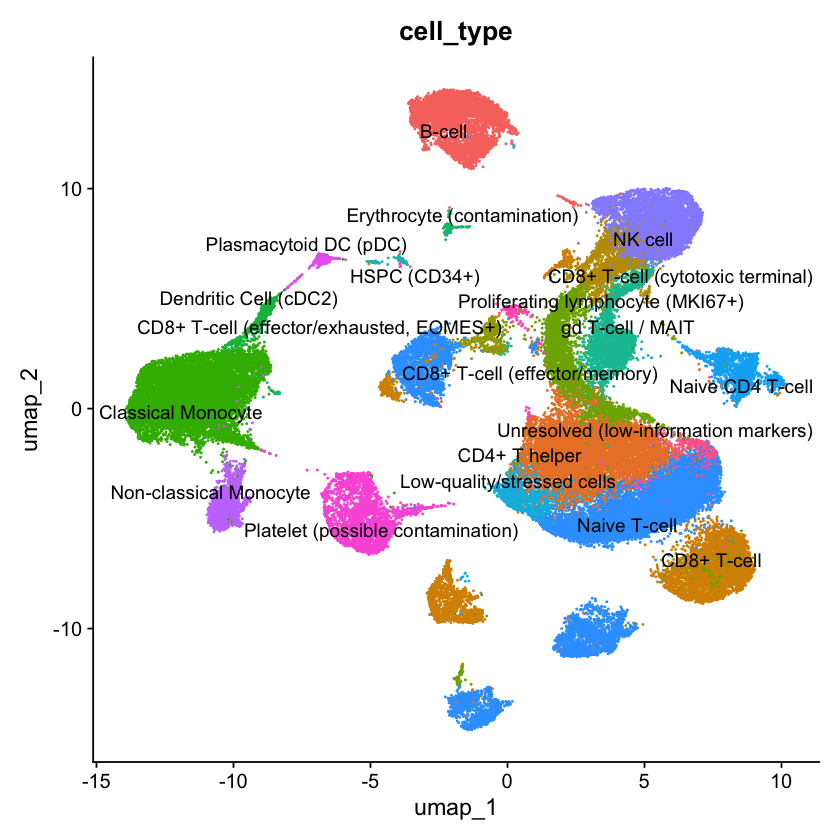

In [6]:
DimPlot(merged_sct, group.by = "cell_type", label = TRUE, repel = TRUE) +
  theme(legend.position = "none")
ggsave("/Users/mehranbeyki/portfolio-projects/scrna-immune-checkpoint-response/results/figures/umap_annotated_celltype.png", width = 10, height = 8, dpi = 300)
 

# T-cell exhaustion

## T-cell subset

In [7]:
t_cell_clusters <- c("1","2","5","6","7","8","10","11","13","14","15","18","22","25")
t_cells <- subset(merged_sct, cell_type %in% cluster_labels[t_cell_clusters])
 


### T-cell exhaustion

In [8]:
exhaustion_markers <- c("PDCD1", "CTLA4", "LAG3", "HAVCR2", "TOX", "TIGIT")
exhaustion_markers <- intersect(exhaustion_markers, rownames(t_cells))
 


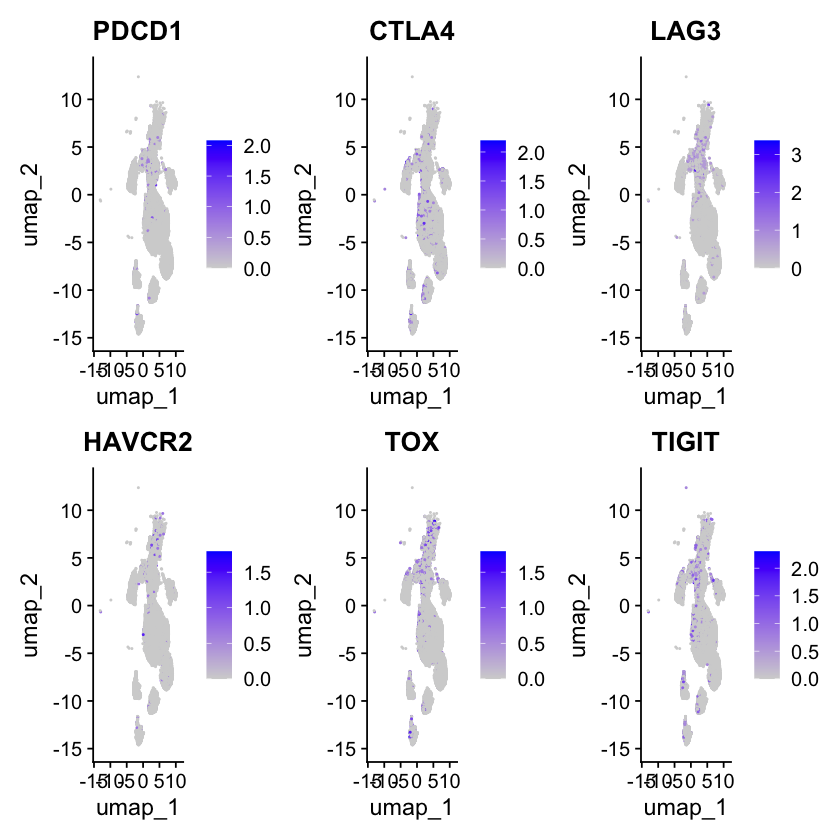

Warning message:
“Scaling data with a low number of groups may produce misleading results”


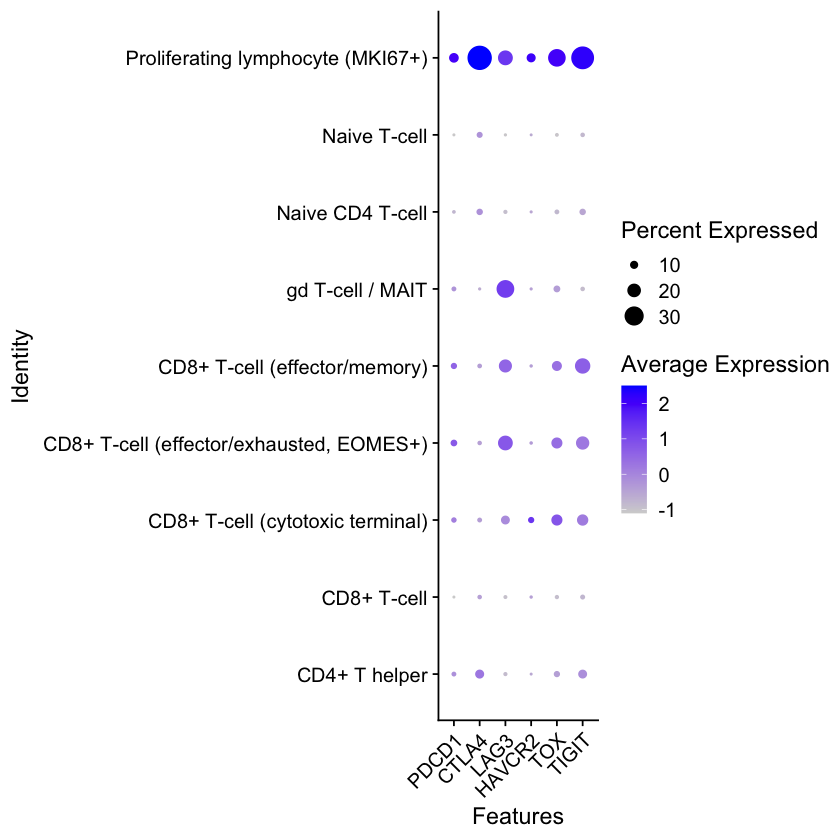

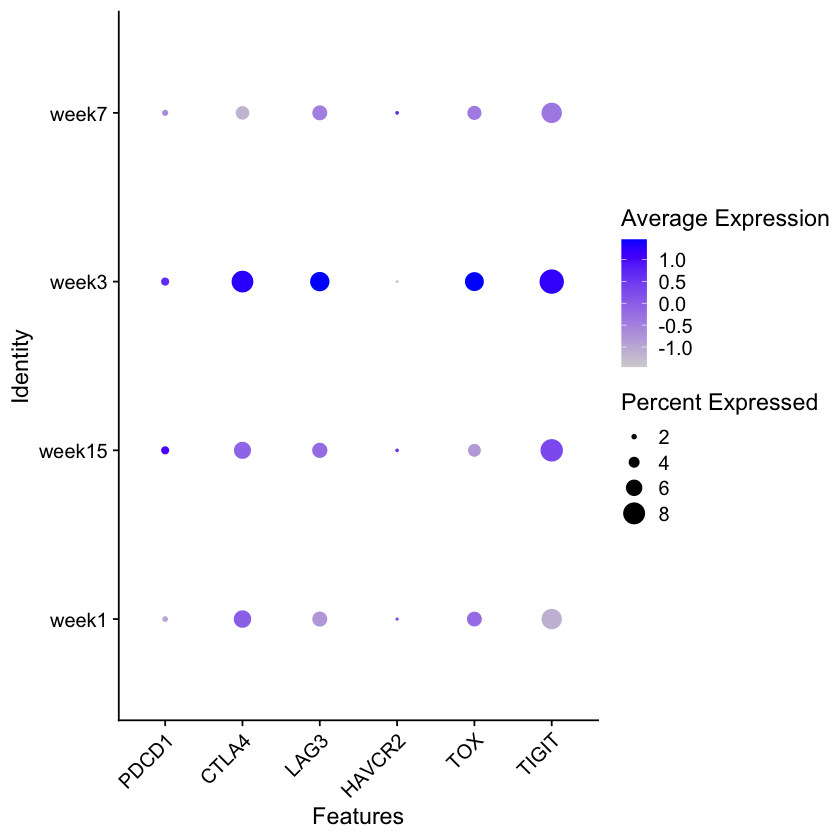

In [9]:
FeaturePlot(t_cells, features = exhaustion_markers, ncol = 3)
ggsave("//Users/mehranbeyki/portfolio-projects/scrna-immune-checkpoint-response/results/figures/featureplot_exhaustion_markers_Tcells.png",
       width = 14, height = 9, dpi = 300)
 
DotPlot(t_cells, features = exhaustion_markers, group.by = "cell_type") + RotatedAxis()
ggsave("//Users/mehranbeyki/portfolio-projects/scrna-immune-checkpoint-response/results/figures/dotplot_exhaustion_by_Tsubtype.png", width = 10, height = 6, dpi = 300)
 
# the following dotplot shows the expression of exhaustion markers across different timepoints (pre-treatment, on-treatment, post-treatment)
DotPlot(t_cells, features = exhaustion_markers, group.by = "timepoint") + RotatedAxis()
ggsave("//Users/mehranbeyki/portfolio-projects/scrna-immune-checkpoint-response/results/figures/dotplot_exhaustion_by_timepoint.png", width = 10, height = 6, dpi = 300)
 
saveRDS(merged_sct, "//Users/mehranbeyki/portfolio-projects/scrna-immune-checkpoint-response/data/processed/merged_annotated_final.rds")
saveRDS(t_cells, "//Users/mehranbeyki/portfolio-projects/scrna-immune-checkpoint-response/data/processed/tcells_subset.rds")